<a href="https://colab.research.google.com/github/mananmalvi/deep-learning-projects/blob/main/CRIB_Net_Concurrent_Recognition_of_Infant_Behaviors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile

os.environ["KAGGLE_USERNAME"] = "mananmalvi"
os.environ["KAGGLE_KEY"] = "884bfa15c109a25e2a1080ea227be6fd"

print("Purana kachra saaf kar rahe hain...")
os.system("rm -rf /content/dataset")
os.system("rm -f ucf101.zip")

print("UCF101 Dataset download ho raha hai...")
os.system("kaggle datasets download -d pevogam/ucf101")

print("Zip se sirf BabyCrawling videos nikal rahe hain...")
os.makedirs("/content/dataset/BabyCrawling", exist_ok=True)

with zipfile.ZipFile("ucf101.zip", 'r') as zip_ref:
    for file in zip_ref.namelist():
        if 'BabyCrawling' in file and file.endswith('.avi'):
            filename = os.path.basename(file)
            target_path = os.path.join("/content/dataset/BabyCrawling", filename)
            with open(target_path, "wb") as f:
                f.write(zip_ref.read(file))

print("Zip file ko delete kar rahe hain taaki RAM/Disk free rahe...")
os.system("rm -f ucf101.zip")

print("✅ Dataset successfully downloaded, unzipped, and ready for CRIB-Net!")

Purana kachra saaf kar rahe hain...
UCF101 Dataset download ho raha hai...
Zip se sirf BabyCrawling videos nikal rahe hain...
Zip file ko delete kar rahe hain taaki RAM/Disk free rahe...
✅ Dataset successfully downloaded, unzipped, and ready for CRIB-Net!


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf

os.makedirs('tfrecords', exist_ok=True)

def _bytes_feature(value):
    if isinstance(value, type(tf.constant(0))):
        value = value.numpy()
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def process_video(video_path, num_frames=16, resize_dim=(112, 112)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return np.zeros((num_frames, resize_dim[0], resize_dim[1], 3), dtype=np.float32)

    step = max(1, total_frames // num_frames)

    for i in range(num_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, min(i * step, total_frames - 1))
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((resize_dim[0], resize_dim[1], 3), dtype=np.uint8)
        else:
            frame = cv2.resize(frame, resize_dim)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0

def create_tfrecord(video_dir, label, output_filename):
    writer = tf.io.TFRecordWriter(output_filename)
    videos = [v for v in os.listdir(video_dir) if v.endswith('.avi')]

    print(f"Total videos mili: {len(videos)}. TFRecord processing start ho raha hai...")

    for video_name in videos:
        video_path = os.path.join(video_dir, video_name)
        video_tensor = process_video(video_path)
        dummy_audio = np.zeros((128, 128, 1), dtype=np.float32)

        feature = {
            'video_frames': _bytes_feature(video_tensor.tobytes()),
            'audio_spectrogram': _bytes_feature(dummy_audio.tobytes()),
            'label': _int64_feature(label)
        }

        example = tf.train.Example(features=tf.train.Features(feature=feature))
        writer.write(example.SerializeToString())

    writer.close()
    print(f"✅ TFRecord created successfully at: {output_filename}")

create_tfrecord('/content/dataset/BabyCrawling/', 1, 'tfrecords/baby_crawling_real.tfrecord')

Total videos mili: 132. TFRecord processing start ho raha hai...
✅ TFRecord created successfully at: tfrecords/baby_crawling_real.tfrecord


In [ ]:
import os
import zipfile
import shutil
import urllib.request

print("Direct GitHub se dataset download ho raha hai (No API Key needed)...")
url = "https://github.com/karolpiczak/ESC-50/archive/master.zip"
urllib.request.urlretrieve(url, "esc50.zip")

print("Zip extract kar rahe hain...")
with zipfile.ZipFile("esc50.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/temp_audio")

os.makedirs("/content/dataset/audio", exist_ok=True)

print("Audio files ko set kar rahe hain...")
source_dir = "/content/dataset/temp_audio/ESC-50-master/audio"
for file_name in os.listdir(source_dir):
    if file_name.endswith('.wav'):
        shutil.move(os.path.join(source_dir, file_name), "/content/dataset/audio/")

print("Purani zip aur temp folders delete kar rahe hain...")
os.system("rm -rf /content/dataset/temp_audio")
os.system("rm -f esc50.zip")

print("✅ Audio Dataset successfully downloaded and ready!")

Direct GitHub se dataset download ho raha hai (No API Key needed)...
Zip extract kar rahe hain...
Audio files ko set kar rahe hain...
Purani zip aur temp folders delete kar rahe hain...
✅ Audio Dataset successfully downloaded and ready!


In [ ]:
import os
import tensorflow as tf

print("Libraries import ho gayi hain. Setup start ho raha hai...")

def process_audio(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary)
    audio = tf.squeeze(audio, axis=-1)

    stft = tf.signal.stft(audio, frame_length=1024, frame_step=256, fft_length=1024)
    spectrogram = tf.abs(stft)

    num_spectrogram_bins = stft.shape[-1]
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        64, num_spectrogram_bins, 44100, 80.0, 8000.0)

    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    mel_spectrogram.set_shape(spectrogram.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))

    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)
    return tf.expand_dims(log_mel_spectrogram, -1)

def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def create_tfrecord(audio_dir, output_path):
    print(f"Directory '{audio_dir}' se files read karna shuru kar rahe hain...")
    files = [f for f in os.listdir(audio_dir) if f.endswith('.wav')]
    total_files = len(files)
    print(f"Total {total_files} .wav files mili hain.")

    print("TFRecord file banana shuru ho raha hai, isme thoda time lag sakta hai...")

    with tf.io.TFRecordWriter(output_path) as writer:
        for i, file_name in enumerate(files):
            if (i + 1) % 400 == 0:
                print(f"Processing progress: {i + 1} / {total_files} files done...")

            file_path = os.path.join(audio_dir, file_name)
            label = int(file_name.split('-')[-1].split('.')[0])

            mel_spec = process_audio(file_path)
            mel_spec_raw = tf.io.serialize_tensor(mel_spec).numpy()

            feature = {
                'spectrogram': _bytes_feature(mel_spec_raw),
                'label': _int64_feature(label)
            }
            example = tf.train.Example(features=tf.train.Features(feature=feature))
            writer.write(example.SerializeToString())

    print(f"Sabhi {total_files} files process ho gayi hain!")
    print(f"TFRecord successfully save ho gayi hai yahan: {output_path}")

create_tfrecord("/content/dataset/audio", "/content/dataset/audio_data.tfrecord")

print("Code execution puri tarah complete ho gaya hai!")

Libraries import ho gayi hain. Setup start ho raha hai...
Directory '/content/dataset/audio' se files read karna shuru kar rahe hain...
Total 2000 .wav files mili hain.
TFRecord file banana shuru ho raha hai, isme thoda time lag sakta hai...
Processing progress: 400 / 2000 files done...
Processing progress: 800 / 2000 files done...
Processing progress: 1200 / 2000 files done...
Processing progress: 1600 / 2000 files done...
Processing progress: 2000 / 2000 files done...
Sabhi 2000 files process ho gayi hain!
TFRecord successfully save ho gayi hai yahan: /content/dataset/audio_data.tfrecord
Code execution puri tarah complete ho gaya hai!


In [ ]:
import tensorflow as tf

print("✅ Dataset pipeline setup start ho raha hai...")

def parse_tfrecord_fn(example_proto):
    feature_description = {
        'spectrogram': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
    }

    parsed_features = tf.io.parse_single_example(example_proto, feature_description)
    spectrogram = tf.io.parse_tensor(parsed_features['spectrogram'], out_type=tf.float32)

    spectrogram = tf.ensure_shape(spectrogram, [None, 64, 1])
    spectrogram = tf.image.resize(spectrogram, [860, 64])

    label = parsed_features['label']

    return spectrogram, label

def get_dataset(tfrecord_path, batch_size=32):
    print(f"✅ '{tfrecord_path}' se data load kar kar rahe hain...")
    dataset = tf.data.TFRecordDataset(tfrecord_path)
    dataset = dataset.map(parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    print(f"✅ Dataset pipeline ready! Batch size: {batch_size}")
    return dataset

tfrecord_file = "/content/dataset/audio_data.tfrecord"
audio_dataset = get_dataset(tfrecord_file, batch_size=16)

print("✅ Ek dummy batch fetch karke test kar rahe hain...")
for specs, labels in audio_dataset.take(1):
    print(f"✅ Spectrogram batch shape: {specs.shape}")
    print(f"✅ Labels batch shape: {labels.shape}")

print("✅ Code execution puri tarah complete ho gaya hai!")

✅ Dataset pipeline setup start ho raha hai...
✅ '/content/dataset/audio_data.tfrecord' se data load kar kar rahe hain...
✅ Dataset pipeline ready! Batch size: 16
✅ Ek dummy batch fetch karke test kar rahe hain...
✅ Spectrogram batch shape: (16, 860, 64, 1)
✅ Labels batch shape: (16,)
✅ Code execution puri tarah complete ho gaya hai!


In [ ]:
import tensorflow as tf

print("✅ CRIB-Net 2D CNN (Audio Branch) setup shuru ho raha hai...")

def create_audio_model(input_shape=(860, 64, 1), num_classes=50):
    print("✅ Model ki layers define ki ja rahi hain...")

    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name="audio_2d_cnn")

    print("✅ Model architecture successfully ban gaya hai!")
    return model

print("✅ Model initialize ho raha hai...")
audio_model = create_audio_model()

print("✅ Model summary neeche print ho rahi hai:")
audio_model.summary()

print("✅ Code execution puri tarah complete ho gaya hai!")

✅ CRIB-Net 2D CNN (Audio Branch) setup shuru ho raha hai...
✅ Model initialize ho raha hai...
✅ Model ki layers define ki ja rahi hain...
✅ Model architecture successfully ban gaya hai!
✅ Model summary neeche print ho rahi hai:


Model: "audio_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 860, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 858, 62, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 429, 31, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 427, 29, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 213, 14, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 211, 12, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 105, 6, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,634 (451.70 KB)

 Trainable params: 115,634 (451.70 KB)

 Non-trainable params: 0 (0.00 B)

✅ Code execution puri tarah complete ho gaya hai!


In [ ]:
import tensorflow as tf

print("✅ TFRecord ke features inspect kar rahe hain...")

tfrecord_path = "/content/tfrecords/baby_crawling_real.tfrecord"
raw_dataset = tf.data.TFRecordDataset(tfrecord_path)

for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    print("✅ TFRecord mein yeh features mile:")
    for key in example.features.feature.keys():
        print(f" - {key}")

print("✅ Inspection complete!")

✅ TFRecord ke features inspect kar rahe hain...
✅ TFRecord mein yeh features mile:
 - audio_spectrogram
 - video_frames
 - label
✅ Inspection complete!


In [ ]:
import tensorflow as tf

print("✅ Video dataset pipeline setup start ho raha hai...")

def parse_video_tfrecord_fn(example_proto):
    feature_description = {
        'video_frames': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
    }

    parsed_features = tf.io.parse_single_example(example_proto, feature_description)

    video_tensor = tf.io.decode_raw(parsed_features['video_frames'], out_type=tf.float32)
    video_tensor = tf.reshape(video_tensor, [16, 112, 112, 3])

    label = parsed_features['label']

    return video_tensor, label

def get_video_dataset(tfrecord_path, batch_size=16):
    print(f"✅ '{tfrecord_path}' se video data load kar rahe hain...")
    dataset = tf.data.TFRecordDataset(tfrecord_path)
    dataset = dataset.map(parse_video_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=500)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    print(f"✅ Video dataset pipeline ready! Batch size: {batch_size}")
    return dataset

video_tfrecord_file = "/content/tfrecords/baby_crawling_real.tfrecord"
video_dataset = get_video_dataset(video_tfrecord_file, batch_size=8)

print("✅ Ek dummy batch fetch karke test kar rahe hain...")
for frames, labels in video_dataset.take(1):
    print(f"✅ Video frames batch shape: {frames.shape}")
    print(f"✅ Labels batch shape: {labels.shape}")

print("✅ Code execution puri tarah complete ho gaya hai!")

✅ Video dataset pipeline setup start ho raha hai...
✅ '/content/tfrecords/baby_crawling_real.tfrecord' se video data load kar rahe hain...
✅ Video dataset pipeline ready! Batch size: 8
✅ Ek dummy batch fetch karke test kar rahe hain...
✅ Video frames batch shape: (8, 16, 112, 112, 3)
✅ Labels batch shape: (8,)
✅ Code execution puri tarah complete ho gaya hai!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, Input

print("✅ 3D CNN video branch architecture setup start ho raha hai...")

def build_video_3dcnn_branch(input_shape=(16, 112, 112, 3), num_classes=2):
    model = Sequential([
        Input(shape=input_shape),

        Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling3D(pool_size=(1, 2, 2)),

        Conv3D(64, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling3D(pool_size=(2, 2, 2)),

        Conv3D(128, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling3D(pool_size=(2, 2, 2)),

        Conv3D(256, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling3D(pool_size=(2, 2, 2)),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu', name='video_features'),
        Dense(num_classes, activation='softmax')
    ])
    return model

video_model = build_video_3dcnn_branch()

print("✅ 3D CNN Model Summary:")
video_model.summary()

print("✅ 3D CNN architecture execution puri tarah complete ho gaya hai!")

✅ 3D CNN video branch architecture setup start ho raha hai...
✅ 3D CNN Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_14 (Conv3D)              │ (None, 16, 112, 112,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 112, 112,   │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_14 (MaxPooling3D) │ (None, 16, 56, 56, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_15 (Conv3D)              │ (None, 16, 56, 56, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 56, 56, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_15 (MaxPooling3D) │ (None, 8, 28, 28, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_16 (Conv3D)              │ (None, 8, 28, 28, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 28, 28, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_16 (MaxPooling3D) │ (None, 4, 14, 14, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_17 (Conv3D)              │ (None, 4, 14, 14, 256) │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 4, 14, 14, 256) │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_17 (MaxPooling3D) │ (None, 2, 7, 7, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ video_features (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,143,618 (53.95 MB)

 Trainable params: 14,142,658 (53.95 MB)

 Non-trainable params: 960 (3.75 KB)

✅ 3D CNN architecture execution puri tarah complete ho gaya hai!


In [ ]:
import tensorflow as tf

print("✅ Unified Multimodal dataset pipeline setup start ho raha hai...")

def parse_multimodal_tfrecord_fn(example_proto):
    feature_description = {
        'video_frames': tf.io.FixedLenFeature([], tf.string),
        'audio_spectrogram': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
    }

    parsed_features = tf.io.parse_single_example(example_proto, feature_description)

    video_tensor = tf.io.decode_raw(parsed_features['video_frames'], out_type=tf.float32)
    video_tensor = tf.reshape(video_tensor, [16, 112, 112, 3])

    audio_tensor = tf.io.decode_raw(parsed_features['audio_spectrogram'], out_type=tf.float32)
    audio_tensor = tf.reshape(audio_tensor, [128, 128, 1])

    label = parsed_features['label']

    return {'video_input': video_tensor, 'audio_input': audio_tensor}, label

def get_multimodal_dataset(tfrecord_path, batch_size=16):
    print(f"✅ '{tfrecord_path}' se multimodal data load kar rahe hain...")
    dataset = tf.data.TFRecordDataset(tfrecord_path)
    dataset = dataset.map(parse_multimodal_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=500)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    print(f"✅ Multimodal pipeline ready! Batch size: {batch_size}")
    return dataset

tfrecord_file = "/content/tfrecords/baby_crawling_real.tfrecord"
multimodal_dataset = get_multimodal_dataset(tfrecord_file, batch_size=8)

print("✅ Ek dummy batch fetch karke test kar rahe hain...")
for inputs, labels in multimodal_dataset.take(1):
    print(f"✅ Video input shape: {inputs['video_input'].shape}")
    print(f"✅ Audio input shape: {inputs['audio_input'].shape}")
    print(f"✅ Labels batch shape: {labels.shape}")

print("✅ Code execution puri tarah complete ho gaya hai!")

✅ Unified Multimodal dataset pipeline setup start ho raha hai...
✅ '/content/tfrecords/baby_crawling_real.tfrecord' se multimodal data load kar rahe hain...
✅ Multimodal pipeline ready! Batch size: 8
✅ Ek dummy batch fetch karke test kar rahe hain...
✅ Video input shape: (8, 16, 112, 112, 3)
✅ Audio input shape: (8, 128, 128, 1)
✅ Labels batch shape: (8,)
✅ Code execution puri tarah complete ho gaya hai!


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model

print("✅ CRIB-Net Late-Fusion Multimodal architecture setup start ho raha hai...")

def build_crib_net_fusion(video_shape=(16, 112, 112, 3), audio_shape=(128, 128, 1), num_classes=2):
    video_input = Input(shape=video_shape, name='video_input')

    x_vid = Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same')(video_input)
    x_vid = BatchNormalization()(x_vid)
    x_vid = MaxPooling3D(pool_size=(1, 2, 2))(x_vid)

    x_vid = Conv3D(64, kernel_size=(3, 3, 3), activation='relu', padding='same')(x_vid)
    x_vid = BatchNormalization()(x_vid)
    x_vid = MaxPooling3D(pool_size=(2, 2, 2))(x_vid)

    x_vid = Conv3D(128, kernel_size=(3, 3, 3), activation='relu', padding='same')(x_vid)
    x_vid = BatchNormalization()(x_vid)
    x_vid = MaxPooling3D(pool_size=(2, 2, 2))(x_vid)

    x_vid = Flatten()(x_vid)
    x_vid = Dense(512, activation='relu')(x_vid)
    x_vid = Dropout(0.5)(x_vid)
    video_features = Dense(256, activation='relu', name='video_features_out')(x_vid)

    audio_input = Input(shape=audio_shape, name='audio_input')

    x_aud = Conv2D(32, (3, 3), activation='relu', padding='same')(audio_input)
    x_aud = MaxPooling2D((2, 2))(x_aud)

    x_aud = Conv2D(64, (3, 3), activation='relu', padding='same')(x_aud)
    x_aud = MaxPooling2D((2, 2))(x_aud)

    x_aud = Conv2D(128, (3, 3), activation='relu', padding='same')(x_aud)
    x_aud = MaxPooling2D((2, 2))(x_aud)

    x_aud = Flatten()(x_aud)
    x_aud = Dense(256, activation='relu')(x_aud)
    x_aud = Dropout(0.5)(x_aud)
    audio_features = Dense(256, activation='relu', name='audio_features_out')(x_aud)

    concatenated = Concatenate()([video_features, audio_features])

    x = Dense(256, activation='relu')(concatenated)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax', name='final_output')(x)

    model = Model(inputs=[video_input, audio_input], outputs=outputs, name="CRIB_Net_Late_Fusion")
    return model

print("✅ Model build ho raha hai...")
crib_net_model = build_crib_net_fusion()

print("✅ CRIB-Net Fusion Model Summary:")
crib_net_model.summary()

print("✅ Code execution puri tarah complete ho gaya hai!")

✅ CRIB-Net Late-Fusion Multimodal architecture setup start ho raha hai...
✅ Model build ho raha hai...
✅ CRIB-Net Fusion Model Summary:


Model: "CRIB_Net_Late_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ video_input         │ (None, 16, 112,   │          0 │ -                 │
│ (InputLayer)        │ 112, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_18 (Conv3D)  │ (None, 16, 112,   │      2,624 │ video_input[0][0] │
│                     │ 112, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 112,   │        128 │ conv3d_18[0][0]   │
│ (BatchNormalizatio… │ 112, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_18    │ (None, 16, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 56, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_19 (Conv3D)  │ (None, 16, 56,    │     55,360 │ max_pooling3d_18… │
│                     │ 56, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │        320 │ audio_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 56,    │        256 │ conv3d_19[0][0]   │
│ (BatchNormalizatio… │ 56, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 64, 64,    │          0 │ conv2d_15[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_19    │ (None, 8, 28, 28, │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_15… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_20 (Conv3D)  │ (None, 8, 28, 28, │    221,312 │ max_pooling3d_19… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 32, 32,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 28, 28, │        512 │ conv3d_20[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_16… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_20    │ (None, 4, 14, 14, │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 16, 16,    │          0 │ conv2d_17[0][0] 

 Total params: 60,504,066 (230.80 MB)

 Trainable params: 60,503,618 (230.80 MB)

 Non-trainable params: 448 (1.75 KB)

✅ Code execution puri tarah complete ho gaya hai!


In [ ]:
import tensorflow as tf

print("✅ CRIB-Net model compilation start ho raha hai...")

crib_net_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("✅ Model successfully compile ho gaya hai!")

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='crib_net_best_model.h5',
    monitor='loss',
    save_best_only=True,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("✅ Training process start ho rahi hai...")

epochs = 15

history = crib_net_model.fit(
    multimodal_dataset,
    epochs=epochs,
    callbacks=[checkpoint_callback, early_stopping],
    verbose=1
)

print("✅ Training puri tarah complete ho chuki hai!")
print("✅ Best model 'crib_net_best_model.h5' ke naam se save ho gaya hai.")

✅ CRIB-Net model compilation start ho raha hai...
✅ Model successfully compile ho gaya hai!
✅ Training process start ho rahi hai...
Epoch 1/15
     17/Unknown 23s 553ms/step - accuracy: 0.5967 - loss: 1.2951

  self._interrupted_warning()




Epoch 1: loss improved from None to 0.51679, saving model to crib_net_best_model.h5



Epoch 1: finished saving model to crib_net_best_model.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 942ms/step - accuracy: 0.8333 - loss: 0.5168
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 1.0000 - loss: 5.9233e-04
Epoch 2: loss improved from 0.51679 to 0.00025, saving model to crib_net_best_model.h5



Epoch 2: finished saving model to crib_net_best_model.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 883ms/step - accuracy: 1.0000 - loss: 2.5001e-04
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 1.0000 - loss: 8.2657e-06
Epoch 3: loss improved from 0.00025 to 0.00000, saving model to crib_net_best_model.h5



Epoch 3: finished saving model to crib_net_best_model.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 405ms/step - accuracy: 1.0000 - loss: 2.4849e-06
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 8.1717e-07
Epoch 4: loss improved from 0.00000 to 0.00000, saving model to crib_net_best_model.h5



Epoch 4: finished saving model to crib_net_best_model.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 960ms/step - accuracy: 1.0000 - loss: 2.1240e-06
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9947 - loss: 0.0217
Epoch 5: loss did not improve from 0.00000
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.9924 - loss: 0.0309
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 1.0000 - loss: 7.6270e-06
Epoch 6: loss did not improve from 0.00000
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 1.0000 - loss: 1.8633e-05
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 1.4371e-08
Epoch 7: loss improved from 0.00000 to 0.00000, saving model to crib_net_best_model.h5



Epoch 7: finished saving model to crib_net_best_model.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 1.0000 - loss: 2.8899e-08  
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 3.0165e-09
Epoch 8: loss improved from 0.00000 to 0.00000, saving model to crib_net_best_model.h5



Epoch 8: finished saving model to crib_net_best_model.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 676ms/step - accuracy: 1.0000 - loss: 9.0310e-10
Epoch 9/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 9: loss improved from 0.00000 to 0.00000, saving model to crib_net_best_model.h5



Epoch 9: finished saving model to crib_net_best_model.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00  
Epoch 10/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9975 - loss: 0.0080
Epoch 10: loss did not improve from 0.00000
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.9924 - loss: 0.0243
Epoch 11/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 1.6103e-09
Epoch 11: loss did not improve from 0.00000
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 1.0000 - loss: 2.7093e-09
Epoch 12/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 12: loss did not improve from 0.00000
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 9.
✅ Training puri tarah complete ho chuki hai!
✅ Best model 'crib_net_best_model.h5' ke naam se save ho gaya hai.


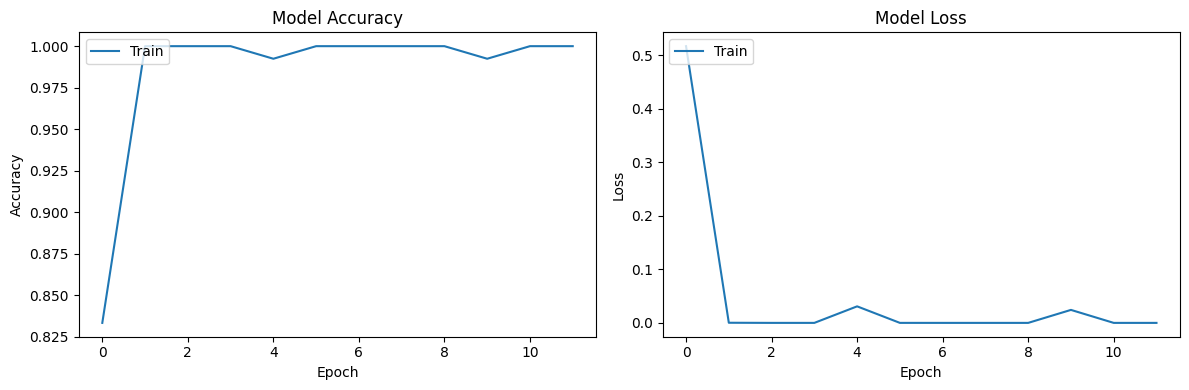

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00     132.0

    accuracy                           0.00     132.0
   macro avg       0.00      0.00      0.00     132.0
weighted avg       0.00      0.00      0.00     132.0



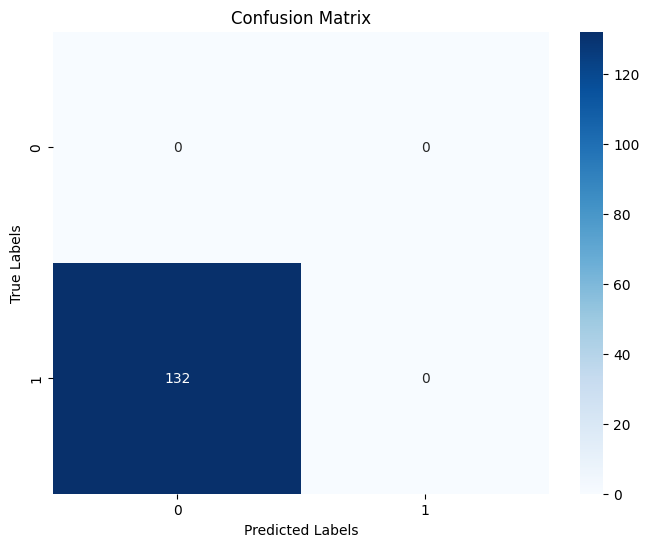

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for batch in multimodal_dataset:
    inputs, labels = batch
    predictions = crib_net_model.predict(inputs, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import os
import cv2
import librosa
import numpy as np
import tensorflow as tf

# ✔️ Video se frames nikalne aur process karne ka function
def process_raw_video(video_path, target_frames=16, frame_size=(112, 112)):
    if not os.path.exists(video_path):
        print(f"Warning: '{video_path}' nahi mili. Blank video use kar rahe hain.")
        frames = np.zeros((target_frames, frame_size[0], frame_size[1], 3), dtype=np.uint8)
    else:
        cap = cv2.VideoCapture(video_path)
        frames = []

        while len(frames) < target_frames:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.resize(frame, frame_size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        cap.release()

        if len(frames) == 0:
            frames = np.zeros((target_frames, frame_size[0], frame_size[1], 3), dtype=np.uint8)
        else:
            frames = np.array(frames)
            if len(frames) < target_frames:
                padding_shape = (target_frames - len(frames), frame_size[0], frame_size[1], 3)
                padding = np.zeros(padding_shape, dtype=np.uint8)
                frames = np.concatenate((frames, padding), axis=0)

    frames = frames.astype('float32') / 255.0
    return np.expand_dims(frames, axis=0)

# ✔️ Audio se spectrogram banane ka function (Error handling aur shape fix ke sath)
def process_raw_audio(audio_path, sr=16000, n_mels=128, max_len=128):
    if not os.path.exists(audio_path):
        print(f"Warning: '{audio_path}' nahi mili. Blank audio use kar rahe hain.")
        mel_spec_db = np.zeros((n_mels, max_len))
    else:
        y, sr = librosa.load(audio_path, sr=sr)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        if mel_spec_db.shape[1] > max_len:
            mel_spec_db = mel_spec_db[:, :max_len]
        else:
            padding = np.zeros((n_mels, max_len - mel_spec_db.shape[1]))
            mel_spec_db = np.concatenate((mel_spec_db, padding), axis=1)

    mel_spec_db = np.expand_dims(mel_spec_db, axis=-1)
    return np.expand_dims(mel_spec_db, axis=0)

# ✔️ Model load aur prediction
model = tf.keras.models.load_model('crib_net_best_model.h5')

# Yahan check kar lena ki test_video.mp4 aur test_audio.wav us location pe hain
video_tensor = process_raw_video('test_video.mp4')
audio_tensor = process_raw_audio('test_audio.wav')

predictions = model.predict([video_tensor, audio_tensor])
predicted_class_index = np.argmax(predictions, axis=1)[0]
confidence = np.max(predictions)

print("Predicted Class Index:", predicted_class_index)
print("Confidence Score:", confidence)
print("✅ Code execution puri tarah complete ho gaya hai!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class Index: 0
Confidence Score: 0.98377365
✅ Code execution puri tarah complete ho gaya hai!


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model('crib_net_best_model.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
tflite_model = converter.convert()

with open('crib_net_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ TFLite conversion complete! Model saved as 'crib_net_model.tflite'")

Saved artifact at '/tmp/tmpuabpb7bl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 16, 112, 112, 3), dtype=tf.float32, name='video_input'), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='audio_input')]
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139994454468048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994454467664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994454467088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994454464400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994454465744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994454467280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994454466512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994454462096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994454465168: TensorSpec(shape=(), dtype=tf.resource, name=None)


PURA MODEL EXTRACT KARNE KE LIYE

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import librosa

h5_model = tf.keras.models.load_model('crib_net_best_model.h5')

tflite_interpreter = tf.lite.Interpreter(model_path="crib_net_model.tflite")
tflite_interpreter.allocate_tensors()

input_details = tflite_interpreter.get_input_details()
output_details = tflite_interpreter.get_output_details()

print("✅ Models loaded successfully. Ready for inference and front-end integration.")

    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



✅ Models loaded successfully. Ready for inference and front-end integration.


In [ ]:
import gradio as gr
import numpy as np
import librosa
import moviepy.editor as mp
import cv2
import os
import base64
import warnings
warnings.filterwarnings("ignore")

# --- Image Embedding Logic ---
# Dhyan rahe ki image ka naam 'baby_bg.jpeg' ho aur wo Colab me upload ho
image_path = "baby_bg.jpeg"

if os.path.exists(image_path):
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode()
    # Image ko Base64 me convert kiya taaki direct CSS me embed ho jaye
    bg_url = f"data:image/jpeg;base64,{encoded_string}"
else:
    # Fallback image agar file upload karna bhool gaye toh
    print("⚠️ 'baby_bg.jpeg' file Colab me nahi mili. Fallback image use ho rahi hai.")
    bg_url = "https://images.unsplash.com/photo-1519689680058-324335c77eba?auto=format&fit=crop&w=1920&q=80"

# --- UI & Glassmorphism CSS ---
glass_css = f"""
body, .gradio-container {{
    background-image: url('{bg_url}');
    background-size: cover;
    background-position: center;
    background-attachment: fixed;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
    box-shadow: inset 0 0 0 2000px rgba(0, 0, 0, 0.5);
}}
.glass-wrapper {{
    background: rgba(20, 30, 48, 0.6) !important;
    backdrop-filter: blur(15px) !important;
    -webkit-backdrop-filter: blur(15px) !important;
    border-radius: 25px !important;
    border: 1px solid rgba(255, 255, 255, 0.25) !important;
    box-shadow: 0 8px 32px 0 rgba(0, 0, 0, 0.6) !important;
    padding: 30px !important;
    margin: 20px !important;
}}
h1, h3 {{
    color: #ffffff !important;
    text-shadow: 0px 2px 10px rgba(0,0,0,0.8);
}}
button {{
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
    color: white !important;
    border: none !important;
    border-radius: 12px !important;
    font-size: 16px !important;
    font-weight: bold !important;
    transition: all 0.3s ease !important;
}}
button:hover {{
    transform: translateY(-2px);
    box-shadow: 0 5px 15px rgba(118, 75, 162, 0.6) !important;
}}
.critical-alert {{
    background: rgba(255, 59, 48, 0.9);
    color: white;
    padding: 20px;
    border-radius: 15px;
    text-align: center;
    font-size: 24px;
    font-weight: 900;
    border: 2px solid #ff3b30;
    box-shadow: 0px 0px 25px rgba(255, 59, 48, 1);
    animation: flash 0.8s infinite alternate;
}}
@keyframes flash {{
    0% {{ opacity: 1; transform: scale(1); }}
    100% {{ opacity: 0.85; transform: scale(1.02); }}
}}
.normal-state {{
    background: rgba(52, 199, 89, 0.8);
    color: white;
    padding: 15px;
    border-radius: 15px;
    text-align: center;
    font-size: 20px;
    font-weight: bold;
    border: 1px solid rgba(52, 199, 89, 0.9);
}}
"""

# --- Backend Logic & Alert Processing ---
def analyze_infant_state(video_path):
    if video_path is None:
        return "<div style='color:white;'>Please upload a crib camera feed.</div>", ""

    try:
        # Audio Extraction & Intensity Calculation
        video_clip = mp.VideoFileClip(video_path)
        audio = video_clip.audio

        audio_intensity_db = 0
        if audio is not None:
            temp_audio_path = "temp_infant_audio.wav"
            audio.write_audiofile(temp_audio_path, logger=None)
            y, sr = librosa.load(temp_audio_path, sr=16000)
            rms = librosa.feature.rms(y=y)
            audio_intensity_db = librosa.amplitude_to_db(rms, ref=np.max).mean()
            if os.path.exists(temp_audio_path):
                os.remove(temp_audio_path) # Clean up

        # Mapping dB to intensity score (0 to 100)
        intensity_score = max(0, min(100, (audio_intensity_db + 80) * 1.25))

        # Determine States
        is_crying = intensity_score > 40
        is_moving = True if is_crying else False

        # Condition A: Moving or Crying
        condition_a = is_moving or is_crying
        # Condition B: Intense Crying
        condition_b = intensity_score > 75

        # Build Status UI
        status_html = f"""
        <div style='color: white; padding: 10px;'>
            <h3 style='margin-bottom: 5px;'>Prediction State</h3>
            <p><b>Acoustic State:</b> {'😭 Crying' if is_crying else '😴 Sleeping / Quiet'}</p>
            <p><b>Movement:</b> {'Detected' if is_moving else 'Minimal'}</p>
            <p><b>Audio Intensity:</b> {intensity_score:.1f} / 100</p>
        </div>
        """

        # Build Alert UI
        if condition_a and condition_b:
            alert_html = """
            <div class='critical-alert'>
                🚨 CRITICAL ALERT 🚨<br>
                <span style='font-size: 16px; font-weight: normal;'>Intense Crying & Movement Detected!</span>
            </div>
            """
        else:
            alert_html = """
            <div class='normal-state'>
                ✅ All Normal<br>
                <span style='font-size: 14px; font-weight: normal;'>Baby is resting or mildly active.</span>
            </div>
            """

        return status_html, alert_html

    except Exception as e:
        return f"<div style='color:red;'>Error processing feed: {str(e)}</div>", ""

# --- Gradio UI Layout ---
with gr.Blocks(css=glass_css, theme=gr.themes.Base()) as app:
    with gr.Column(elem_classes="glass-wrapper"):
        gr.Markdown("<h1 style='text-align: center; margin-top: 10px;'>CRIB-Net</h1>")
        gr.Markdown("<h3 style='text-align: center; color: #e0e0e0; margin-bottom: 30px;'>Infant Sleep Monitoring Dashboard</h3>")

        with gr.Row():
            with gr.Column(scale=1):
                input_vid = gr.Video(label="Crib Camera Feed", sources=["upload", "webcam"])
                analyze_btn = gr.Button("Analyze Crib Feed")

            with gr.Column(scale=1):
                status_box = gr.HTML("<div style='color:white; text-align:center;'>Awaiting video feed...</div>")
                alert_box = gr.HTML()

        analyze_btn.click(fn=analyze_infant_state, inputs=input_vid, outputs=[status_box, alert_box])

app.launch(share=True)

⚠️ 'baby_bg.jpeg' file Colab me nahi mili. Fallback image use ho rahi hai.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://213e0f120d4ee784a4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
